<img src="../assets/ga-logo.png" style="float: left; margin: 20px; height: 55px">

# Exercise - `pandas` Data Transformation

---

In [144]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy.stats import boxcox

## Part A: Load and Clean

#### 1. Load `College.csv`

- The first column doesn't have an accurate name, rename it.

In [145]:
college=pd.read_csv('./data/College.csv')
college = college.rename(columns={college.columns[0]: 'University'})
college.head()

,University,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


#### 2. Check the shape, the data types of each column, and the number of missing values per column

In [146]:
#check shape
print(college.shape)


(777, 19)


In [147]:
#check types
print(college.dtypes)

University         str
Private            str
Apps             int64
Accept           int64
Enroll           int64
Top10perc        int64
Top25perc        int64
F.Undergrad      int64
P.Undergrad      int64
Outstate         int64
Room.Board       int64
Books            int64
Personal         int64
PhD                str
Terminal         int64
S.F.Ratio      float64
perc.alumni      int64
Expend           int64
Grad.Rate        int64
dtype: object


In [148]:
#check null values
college.isnull().sum()

University     0
Private        0
Apps           0
Accept         0
Enroll         0
Top10perc      0
Top25perc      0
F.Undergrad    0
P.Undergrad    0
Outstate       0
Room.Board     0
Books          0
Personal       0
PhD            0
Terminal       0
S.F.Ratio      0
perc.alumni    0
Expend         0
Grad.Rate      0
dtype: int64

#### 3. Fix the `PhD` column

- `PhD` is the percentage of faculty with a PhD, but it has inaccurate entries.
- Fix the column and fill these entries with the plausible values.

In [149]:
college['PhD'] = pd.to_numeric(college['PhD'], errors='coerce')
college.loc[college['PhD'] > 100, 'PhD'] = np.nan

college['PhD'] = college['PhD'].fillna(college['PhD'].median())

print(college['PhD'].unique())

[ 70.  29.  53.  92.  76.  75.  90.  89.  79.  40.  82.  73.  60.  36.
  78.  48.  62.  69.  83.  55.  88.  57.  93.  85.  65.  66.  81.  59.
  58.  68.  98.  71.  74.  61.  35.  87.  80.  63.  39.  99. 100.  95.
  77.  72.  64.  10.  86.  22.  50.  41.   8.  67.  94.  56.  46.  54.
  84.  97.  51.  42.  49.  52.  43.  37.  45.  47.  91.  31.  96.  34.
  33.  44.  32.  14.  26.  16.]


#### 4. Fix the `Grad.Rate` column

- `Grad.Rate` is the graduation rate, but it has data entry errors.

In [150]:
college['Grad.Rate'] = pd.to_numeric(college['Grad.Rate'], errors='coerce')

# Filter out rows where PhD is greater than 100
college = college[college['Grad.Rate'] <= 100]

## Part B: Diagnose, Transform, and Visualize Skew

#### The tables bellow can be used as a reference to classify the the degree and distribution of the skewness as well as the right distribution transformation method.

### Table1: Skewness Score Interpretation

| Skewness Score Range | Distribution Shape | 
| :--- | :--- | 
| **Less than -1** | Highly Skewed (Left) | 
| **Between -1 and -0.5** | Moderately Skewed (Left) | 
| **Between -0.5 and 0.5** | `Normal (Symmetrical)` | 
| **Between 0.5 and 1** | Moderately Skewed (Right) | 
| **Greater than 1** | Highly Skewed (Right) | 

### Table2: Decision Matrix: Choosing the Right Distribution Transformation

| Transformation | Best Data Shape / Scenario | Handles Zeros? | Handles Negatives? | Impact on Linear Models / Interpretability |
| :--- | :--- | :--- | :--- | :--- |
| **Log Plus One ($\log(x+1)$)** | Highly Right-Skewed with zero counts |  Yes | ❌ No | Safely maps zero values to zero while retaining standard log-compression benefits. |
| **Box-Cox** | Right or Left Skewed (Strictly positive) | ❌ No | ❌ No | Automatically searches for the mathematically ideal power exponent ($\lambda$) to maximize normality. |
| **Yeo-Johnson** | Right or Left Skewed (Versatile) |  Yes |  Yes | Modifies the Box-Cox algorithm to safely calculate ideal power scales across zeros and negatives. |

#### 5. Write `skew_calc()` with `%%writefile`, then `plot_transformations()` here

- `skew_calc(df)`: for every numeric column, calculate its skewness, classify the degree and direction, and recommend a transformation. Use `%%writefile` to save this into `myutils.py`, then import it.
- `plot_transformations(df, skew_table)`: take a DataFrame together with the output of `skew_calc()`, apply the **best** recommended transformation to each column, and plot the before and after distributions side by side with the skewness labeled on each subplot.

In [151]:

def skew_calc(df):
    results = []
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    
    for col in numeric_cols:
        skew_val = df[col].skew()
        abs_skew = abs(skew_val)
        
        # Determine Direction
        direction = "Positive" if skew_val >= 0 else "Negative"
            
        # Determine Degree of Skewness
        if abs_skew < 0.5:
            degree = "Approximately Symmetric"
        elif abs_skew <= 1.0:
            degree = "Moderately Skewed"
        else:
            degree = "Highly Skewed"
            
        # Recommend Transformation based on degree
        if abs_skew < 0.5:
            recommendation = "None needed"
        else:
            recommendation = "Box-Cox or Yeo-Johnson"
                
        results.append({
            'Feature': col,
            'Skewness': skew_val,
            'Degree': degree,
            'Direction': direction,
            'Recommended Transformation': recommendation
        })
        
    return pd.DataFrame(results)

In [152]:
def plot_transformations(college, skew_table):
    for _, row in skew_table.iterrows():
        feature = row.get('Column', row.get('Feature'))
        recommendation = row.get('Recommendation', row.get('Recommended Transformation'))

        if recommendation in ['None needed', 'None']:
            continue

        original = college[feature].dropna()
        transformed = original.copy()
        method_used = "Box-Cox"

        try:
            if original.min() > 0:
                transformed, _ = boxcox(original)
                method_used = 'Box-Cox'
            else:
                pt = PowerTransformer(method='yeo-johnson')
                transformed = pt.fit_transform(original.values.reshape(-1, 1)).flatten()
                method_used = 'Yeo-Johnson'
        except Exception as e:
            print(f"Error transforming {feature}: {e}")
            continue

        orig_skew = original.skew()
        trans_skew = pd.Series(transformed).skew()

        fig, axes = plt.subplots(1, 2, figsize=(10, 4))

        # Original Plot
        sns.histplot(original, kde=True, ax=axes[0], color='#4c82b4')
        axes[0].set_title(f'Original {feature}\n(Skew: {orig_skew:.2f})')
        axes[0].set_xlabel(feature)

        # Transformed Plot
        sns.histplot(transformed, kde=True, ax=axes[1], color='#4c82b4')
        axes[1].set_title(f'Best transformation: {method_used} for {feature}\n(Skew: {trans_skew:.2f})')

        plt.tight_layout()
        plt.show()

#### 6. Run the functions on your cleaned DataFrame

- Call `skew_calc()` and check the table, does the classification match what you expected for these features?
- Call `plot_transformations()`, is the change significant?

In [153]:
skew_table = skew_calc(college)
skew_table

,Feature,Skewness,Degree,Direction,Recommended Transformation
0,Apps,3.722539,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
1,Accept,3.419725,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
2,Enroll,2.688097,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
3,Top10perc,1.412770,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
4,Top25perc,0.257156,Approximately Symmetric,Positive,None needed
5,F.Undergrad,2.608410,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
6,P.Undergrad,5.690157,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
7,Outstate,0.508025,Moderately Skewed,Positive,Box-Cox or Yeo-Johnson
8,Room.Board,0.478823,Approximately Symmetric,Positive,None needed
9,Books,3.484574,Highly Skewed,Positive,Box-Cox or Yeo-Johnson


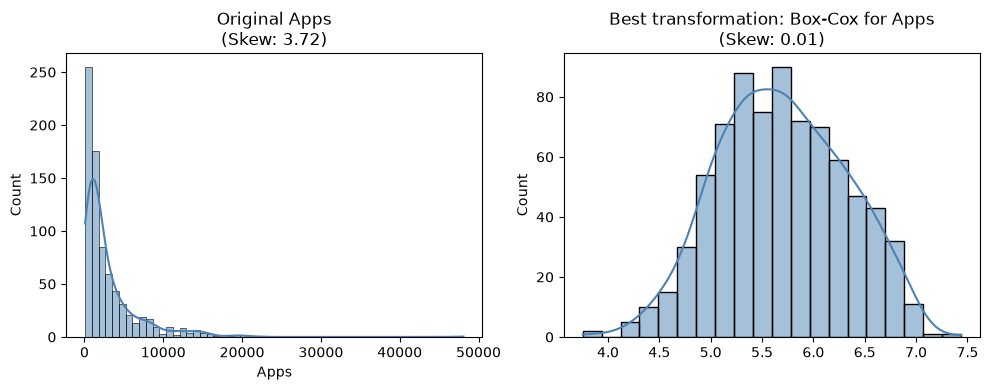

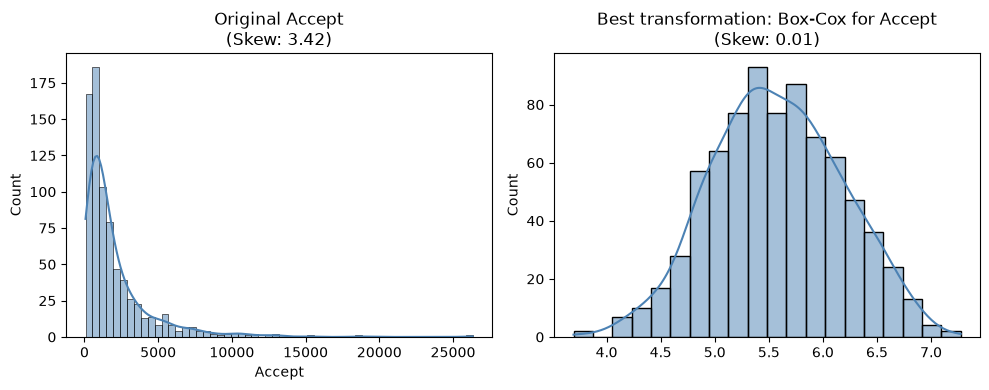

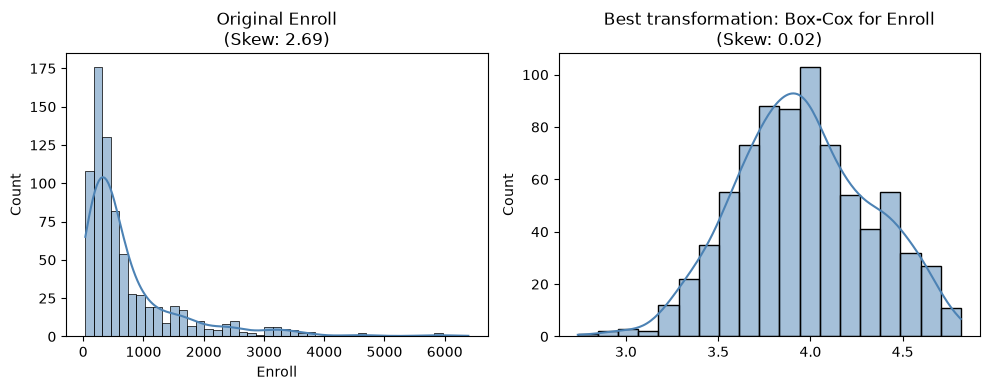

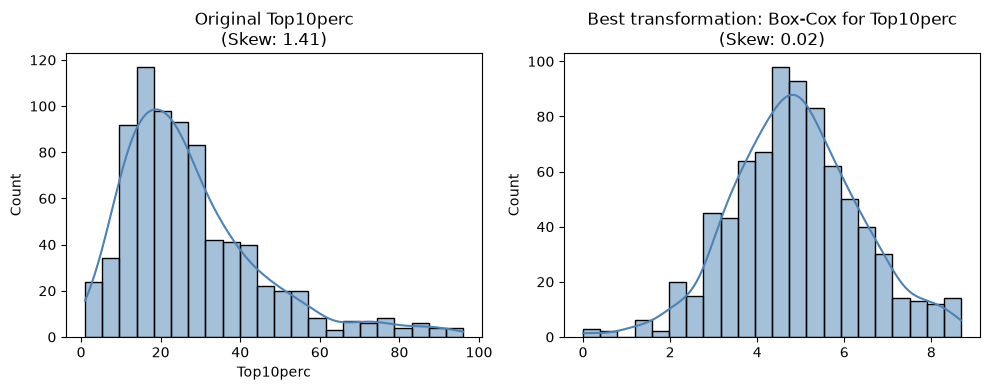

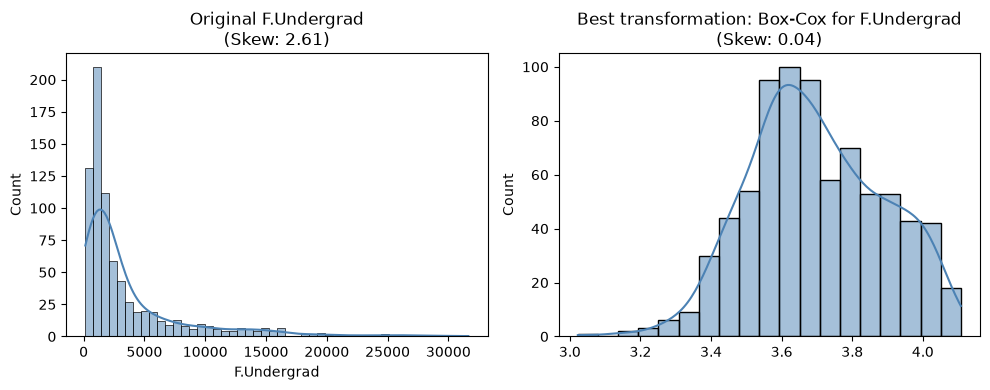

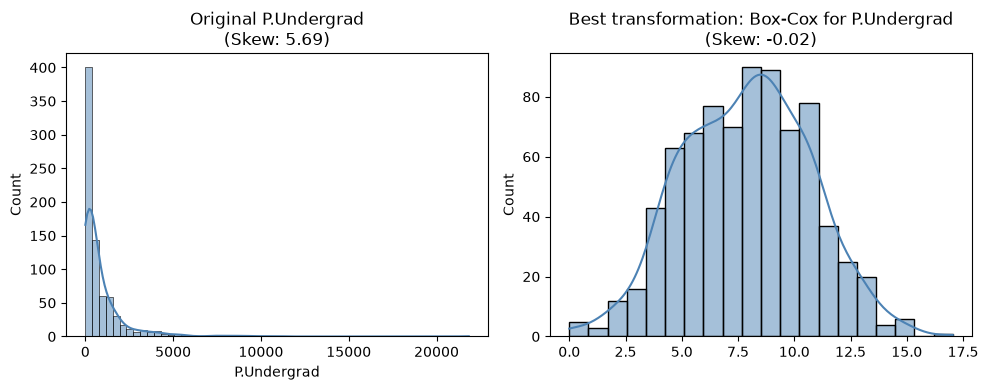

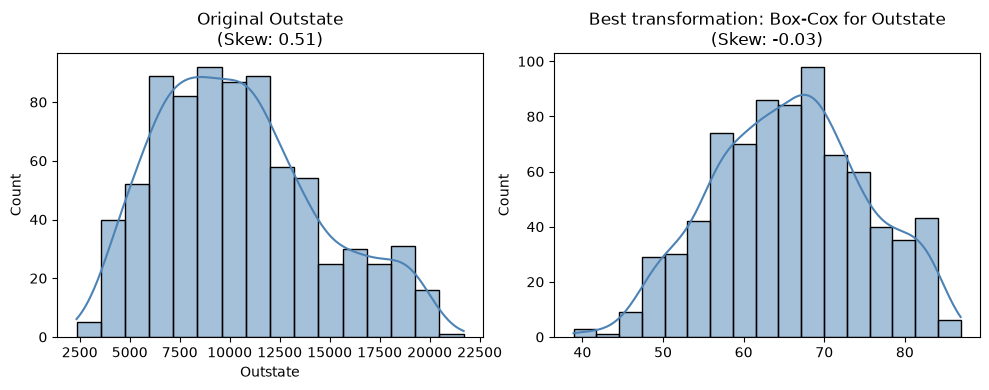

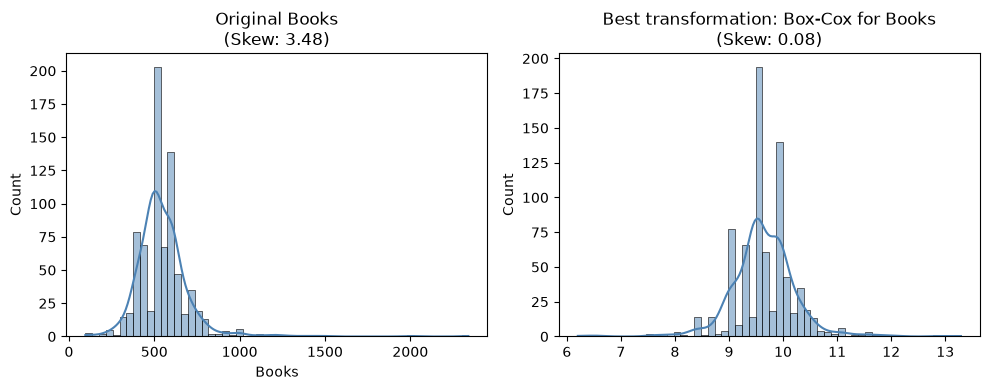

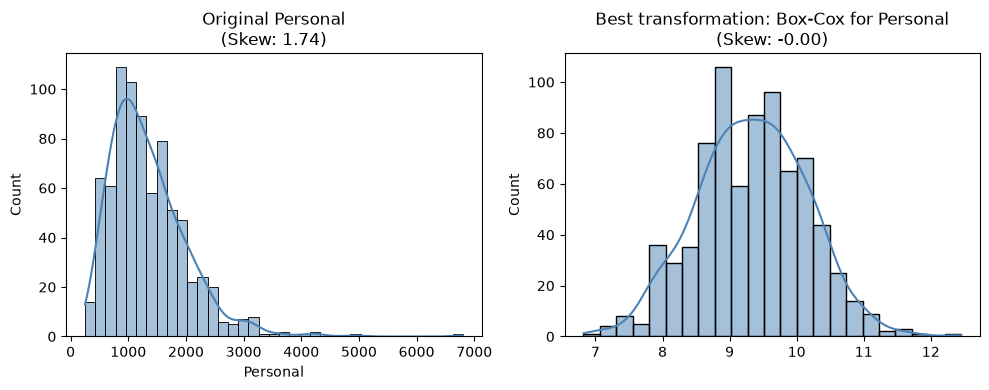

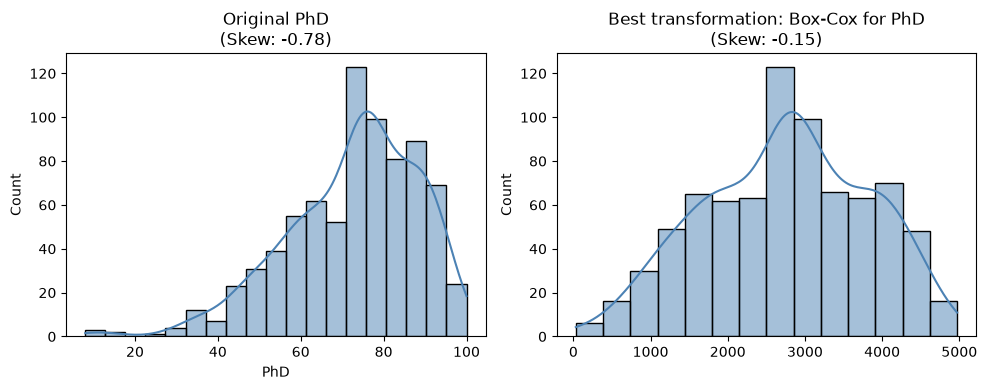

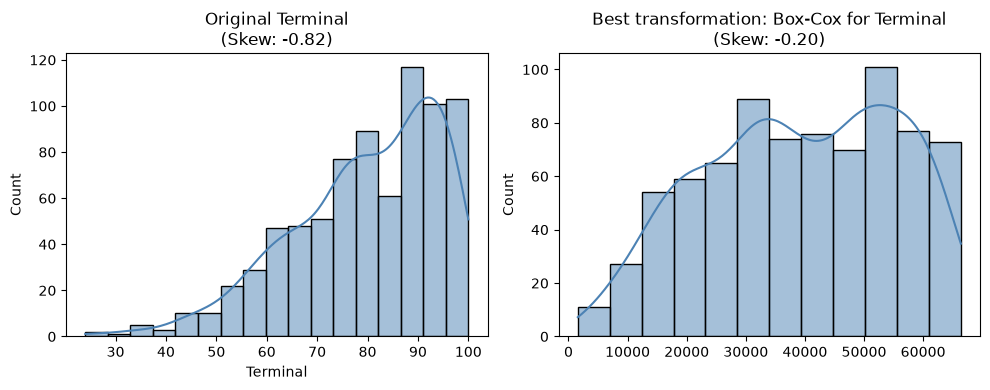

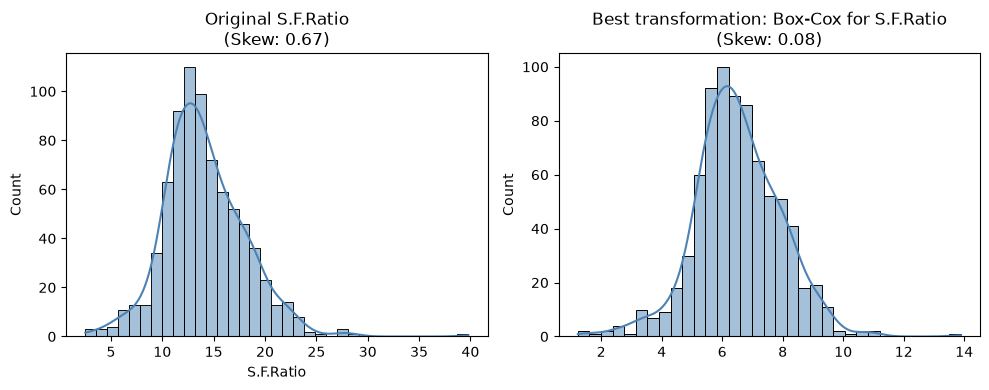

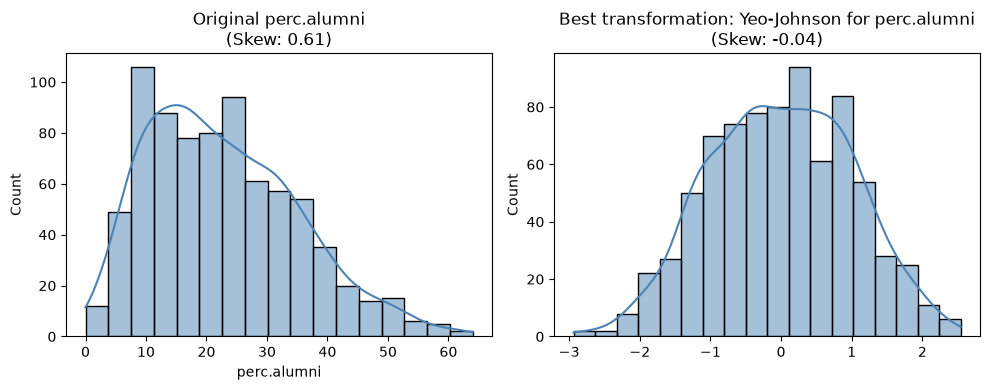

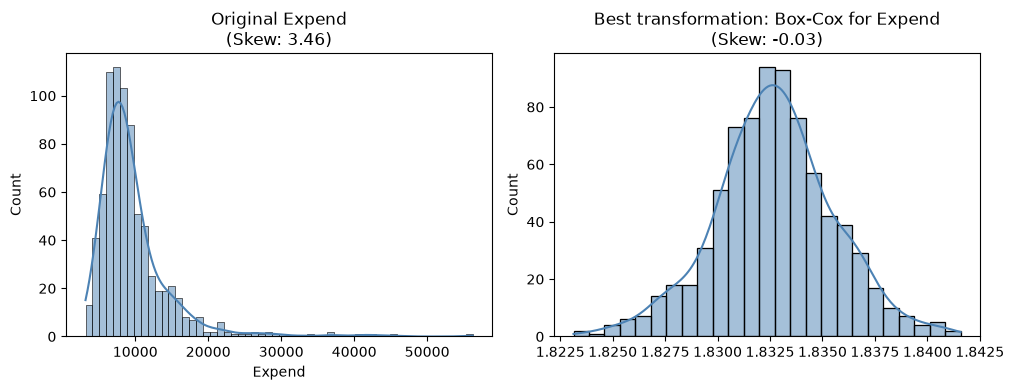

In [154]:
# Call the plotting function
plot_transformations(college, skew_table)

In [155]:
# Your code here

In [156]:
# Your code here

In [157]:
# No code here

## Part C: Apply the transformations

#### 7. Create transformed versions of the skewed columns

- Create a new column for each of the skewed columns based on the recommendations.

In [158]:
import numpy as np
from scipy.stats import boxcox, yeojohnson
from sklearn.preprocessing import PowerTransformer

trans_cols = []

skew_table = skew_calc(college)
skewed_features = skew_table[
    skew_table["Recommended Transformation"] != "None needed"
]

for _, row in skewed_features.iterrows():
    col = row["Feature"]
    rec = row["Recommended Transformation"]
    new_col = f"{col}_transformed"

    if "log(x+1)" in rec or "log" in rec:
        college[new_col] = np.log1p(college[col])
    elif "Box-Cox" in rec and college[col].min() > 0:
        transformed_vals, _ = boxcox(college[col].dropna())
        college.loc[college[col].notna(), new_col] = transformed_vals
    else:
        transformed_vals, _ = yeojohnson(college[col].dropna())
        college.loc[college[col].notna(), new_col] = transformed_vals

    trans_cols.append(new_col)

display(college[trans_cols].head())

,Apps_transformed,Accept_transformed,Enroll_transformed,Top10perc_transformed,F.Undergrad_transformed,P.Undergrad_transformed,Outstate_transformed,Books_transformed,Personal_transformed,PhD_transformed,Terminal_transformed,S.F.Ratio_transformed,perc.alumni_transformed,Expend_transformed
0,5.712146,5.601384,4.140801,4.818997,3.779322,8.713823,59.286015,9.270526,10.371360,2436.789303,34618.546314,7.958871,4.953303,1.831302
1,5.869900,5.867696,4.012907,4.043409,3.766441,10.316165,70.966035,10.425882,9.703858,418.329977,2831.041824,5.904911,5.900305,1.834282
2,5.624503,5.530669,3.846020,4.720064,3.577305,5.815891,68.776468,9.014695,9.273612,1397.252751,22346.509970,6.166254,8.505143,1.832980
3,4.870190,4.801085,3.452449,7.252799,3.408627,5.119822,72.346204,9.270526,8.795946,4207.948159,61289.055912,4.057322,9.567248,1.837638
4,4.362065,4.205271,2.992347,4.043409,3.209291,9.631261,59.628733,10.577310,9.703858,2872.189157,28068.836197,5.791126,1.435571,1.834524


## Part D: Feature Engineering and Encoding

#### 8. Engineer a new feature called `Accept_Rate`

- An acceptance rate is more meaningful than the counts of applicants and accepted students on their own.

In [159]:
# Engineer the new feature Accept_Rate
college['Accept_Rate'] = college['Accept'] / college['Apps']

# Verify the new column
college[['Apps', 'Accept', 'Accept_Rate']].head()

,Apps,Accept,Accept_Rate
0,1660,1232,0.742169
1,2186,1924,0.880146
2,1428,1097,0.768207
3,417,349,0.836930
4,193,146,0.756477


#### 9. Bin `Outstate` into a new column called `Outstate_Tier`

- Use `pd.cut()` to split out-of-state tuition into bins.

In [160]:
# Bin Outstate tuition into 3 tiers using pd.cut()
college['Outstate_Tier'] = pd.cut(
    college['Outstate'], 
    bins=3, 
    labels=['Low', 'Medium', 'High']
)

# Check value counts to verify the tiers
print(college['Outstate_Tier'].value_counts())

Outstate_Tier
Medium    363
Low       302
High      111
Name: count, dtype: int64


#### 10. Ordinally encode `Outstate_Tier`

- Create a new column that maps the tiers ordinally.

In [161]:
# Map tiers ordinally: Low -> 0, Medium -> 1, High -> 2
tier_mapping = {'Low': 0, 'Medium': 1, 'High': 2}

college['Outstate_Tier_Encoded'] = college['Outstate_Tier'].map(tier_mapping)

# Check the mapped values
college[['Outstate_Tier', 'Outstate_Tier_Encoded']].head()

,Outstate_Tier,Outstate_Tier_Encoded
0,Low,0
1,Medium,1
2,Medium,1
3,Medium,1
4,Low,0


#### 11. Binary encode `Private`

- Create a new coumn that maps `Yes` to 1 and `No` to 0.

In [162]:
# Map Private: Yes -> 1, No -> 0
college['Private_Encoded'] = college['Private'].map({'Yes': 1, 'No': 0})

# Check the mapped values
college[['Private', 'Private_Encoded']].head()

,Private,Private_Encoded
0,Yes,1
1,Yes,1
2,Yes,1
3,Yes,1
4,Yes,1


## Part E: Scale and Explore

#### 12. Standardize the transformed and encoded features

- Use `StandardScaler` on all transformed columns from question 7, plus the encoded features and store the results in new columns.

In [163]:
cols_to_scale = trans_cols + ['Accept_Rate', 'Outstate_Tier_Encoded', 'Private_Encoded']
scaler = StandardScaler()
scaled_col_names = [f"{col}_scaled" for col in cols_to_scale]
college[scaled_col_names] = scaler.fit_transform(college[cols_to_scale])

#### 13. Plot a correlation heatmap of your numeric features

- Include the scaled columns from question 12 along with other columns
- Which features look most related to `Grad.Rate`?
- Check and drop highly correlated features

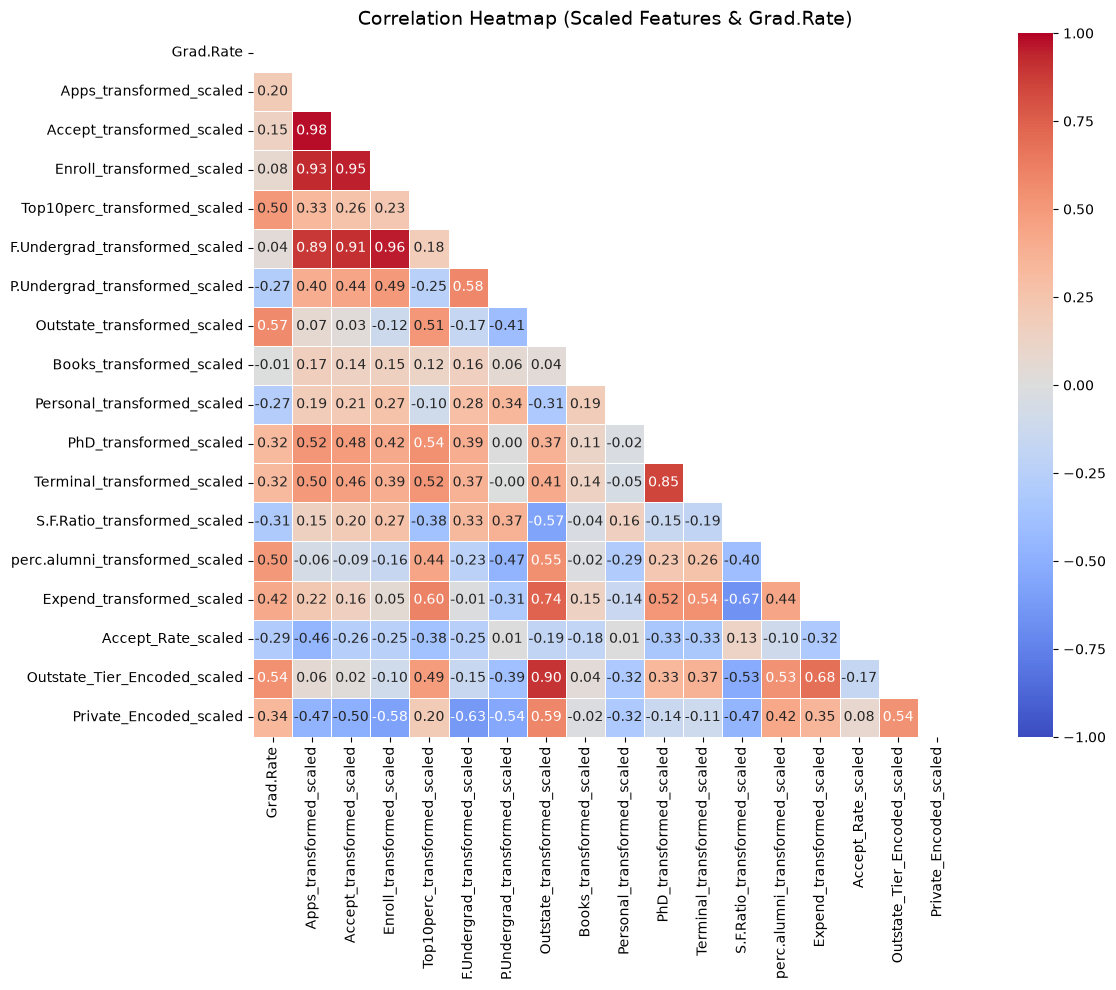

Features most related to Grad.Rate:
Grad.Rate                         1.000000
Outstate_transformed_scaled       0.570917
Outstate_Tier_Encoded_scaled      0.539463
perc.alumni_transformed_scaled    0.502427
Top10perc_transformed_scaled      0.500982
Expend_transformed_scaled         0.418966
Private_Encoded_scaled            0.335860
Terminal_transformed_scaled       0.316912
PhD_transformed_scaled            0.316801
S.F.Ratio_transformed_scaled      0.311915
Accept_Rate_scaled                0.292830
P.Undergrad_transformed_scaled    0.274919
Personal_transformed_scaled       0.266509
Apps_transformed_scaled           0.200882
Accept_transformed_scaled         0.145821
Enroll_transformed_scaled         0.077974
F.Undergrad_transformed_scaled    0.035055
Books_transformed_scaled          0.006663
Name: Grad.Rate, dtype: float64

Highly correlated features to drop (|r| > 0.80): ['Accept_transformed_scaled', 'Enroll_transformed_scaled', 'F.Undergrad_transformed_scaled', 'Terminal_trans

In [164]:
features_to_plot = ['Grad.Rate'] + scaled_col_names
corr_matrix = college[features_to_plot].corr()

# Create lower triangle mask
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot heatmap
features_to_plot = ['Grad.Rate'] + scaled_col_names
corr_matrix = college[features_to_plot].corr()

# Create lower triangle mask
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True, 
    fmt='.2f', 
    cmap='coolwarm', 
    vmin=-1, 
    vmax=1, 
    square=True, 
    linewidths=0.5
)
plt.title('Correlation Heatmap (Scaled Features & Grad.Rate)', fontsize=14)
plt.tight_layout()
plt.show()

# 2. Print features most related to Grad.Rate
grad_rate_corr = corr_matrix['Grad.Rate'].abs().sort_values(ascending=False)
print("Features most related to Grad.Rate:")
print(grad_rate_corr)

# 3. Identify and drop highly correlated feature pairs (|r| > 0.80)
upper_tri = corr_matrix.abs().where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.80)]

print("\nHighly correlated features to drop (|r| > 0.80):", to_drop)

# Drop redundant scaled features from the dataframe
scaled_col_names = [col for col in scaled_col_names if col not in to_drop]

## Part F: Does the Transformation Help?

#### 14. Split your data into train and test sets

- Train the model twice: once using the untransformed columns, and once using the transformed versions, so we can see whether the transformation actually improved the fit
- In both cases, the target will be `Grad.Rate`

In [165]:
y = college['Grad.Rate']
X = college.drop(columns=['Grad.Rate'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### 15. Fit a linear regression using the raw predictors


In [166]:
# Get original column name safely
col_name = 'Column' if 'Column' in skew_table.columns else 'Feature'
untrans_predictors = [col for col in skew_table[col_name] if col != 'Grad.Rate']

model_raw = LinearRegression()
model_raw.fit(X_train[untrans_predictors], y_train)

r2_raw = model_raw.score(X_test[untrans_predictors], y_test)
print("Raw R2 Score:", r2_raw)

Raw R2 Score: 0.4543708571636461


#### 16. Fit the same model using the log-transformed predictors

In [167]:
trans_predictors = trans_cols

model_trans = LinearRegression()
model_trans.fit(X_train[trans_predictors], y_train)

r2_trans = model_trans.score(X_test[trans_predictors], y_test)
print("Transformed R2 Score:", r2_trans)
# Your code here 

Transformed R2 Score: 0.4449428459542769


#### 17. Compare the two R-squared scores

- Is there an improvement in the results?

In [168]:
print(f"Raw Predictors R2: {r2_raw:.4f}")
print(f"Transformed Predictors R2: {r2_trans:.4f}")

if r2_trans > r2_raw:
    print("Yes, transforming the predictors improved the model performance.")
else:
    print("No, the transformation did not improve the model performance.")

Raw Predictors R2: 0.4544
Transformed Predictors R2: 0.4449
No, the transformation did not improve the model performance.


#### 18. Export your cleaned and transformed `DataFrame` to a new CSV file called `college_transformed.csv`

In [169]:
college.to_csv('college_transformed.csv', index=False)